# 05 — LiDAR BEV detection and temporal tracking

*The full dataset remains outside Git. These notebooks combine synthetic worked examples, aggregate evidence, and small attributed qualitative panels.*

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.style.use("seaborn-v0_8-whitegrid")
summary = json.loads((ROOT / "reports" / "benchmark_summary.json").read_text())

## Learning objective and system boundary

This track turns one calibrated ZOD LiDAR sweep into a metric bird's-eye view
(BEV), predicts oriented objects, and links detections through time. It answers
**what occupies the space around the ego vehicle?** It does not choose a route,
plan around an obstacle, or control steering and braking.

```text
raw LiDAR → motion compensation → LiDAR-to-ego SE(3) → 3-channel BEV
          → SFA3D center detector → metric oriented boxes → Kalman tracks
```

The detector is the official MIT-licensed SFA3D FPN-ResNet-18 checkpoint trained
on KITTI, kept outside this repository. The ZOD adapter, rasterizer, evaluator,
tracker, and visualizer are implemented here. This is therefore a fixed
**cross-dataset transfer diagnostic**, not a claim of ZOD-trained performance.

## Coordinate frames and calibration

ZOD ego coordinates are right-handed: (x) forward, (y) left, (z) up.
Raw LiDAR points are first motion-compensated to the keyframe time and then
transformed with the calibrated homogeneous pose

\[
\tilde{\mathbf p}_{ego}=T^{ego}_{lidar}\tilde{\mathbf p}_{lidar},
\qquad \tilde{\mathbf p}=[x,y,z,1]^\top.
\]

The BEV covers (x\in[0,50]) m, (y\in[-25,25]) m, and
(z\in[-1,3]) m. Raster row increases forward; column increases left. The
renderer rotates the array so forward appears at the top while preserving the
metric convention in every model and evaluation calculation.

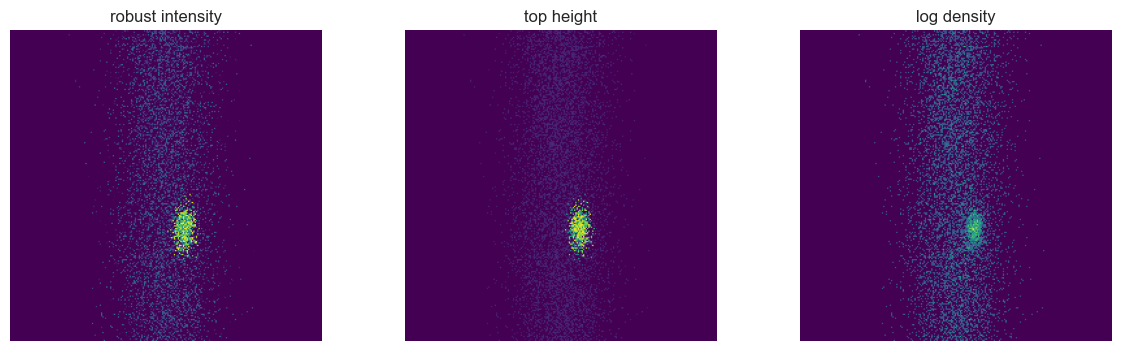

In [2]:
from zod_driveformer.bev import BEVConfig, build_bev_layers

rng=np.random.default_rng(7)
road=np.column_stack((rng.uniform(0,50,7000), rng.normal(0,4,7000), rng.normal(-.8,.04,7000)))
car=np.column_stack((rng.normal(18,1.8,900), rng.normal(-3,0.8,900), rng.uniform(-.6,1.2,900)))
points=np.vstack((road,car)).astype('float32')
intensity=np.r_[rng.uniform(20,90,len(road)),rng.uniform(90,220,len(car))]
demo_cfg=BEVConfig(height=240,width=240)
demo_layers=build_bev_layers(points,intensity,demo_cfg)
fig,ax=plt.subplots(1,3,figsize=(12,3.6))
for axis,layer,title in zip(ax,[demo_layers.intensity,demo_layers.height,demo_layers.density],
                            ['robust intensity','top height','log density']):
    axis.imshow(np.rot90(layer,2),cmap='viridis'); axis.set_title(title); axis.axis('off')
plt.tight_layout(); plt.show()

## Rasterization math

For cell resolution (H\times W), a point is quantized as

\[
r=\left\lfloor H\frac{x-x_{min}}{x_{max}-x_{min}}\right\rfloor,
\quad
c=\left\lfloor W\frac{y-y_{min}}{y_{max}-y_{min}}\right\rfloor.
\]

Within each cell the highest return supplies normalized height
(h=(z-z_{min})/(z_{max}-z_{min})) and robustly percentile-scaled intensity.
All returns contribute to density

\[
d=\min\left(1,\frac{\log(1+n)}{\log 64}\right).
\]

This compresses an unordered point set into three translation-aligned image
channels. It is fast and CNN-friendly, but vertical detail and multiple surfaces
inside one cell are deliberately discarded.

## Detector architecture: center-based oriented boxes

SFA3D uses an FPN-ResNet-18 backbone and several dense heads on a downsampled
BEV feature map:

| Head | Meaning | Decoded output |
|---|---|---|
| `hm_cen` | per-class center heatmap | class and confidence |
| `cen_offset` | sub-cell center correction | continuous (x,y) |
| `direction` | sine/cosine-like orientation pair | yaw (psi) |
| `dim` | object dimensions | length and width |
| `z_coor` | vertical center | retained by SFA3D, outside 2-D metric here |

The heatmap formulation avoids proposing thousands of anchors. Peak decoding
selects at most 50 centers above the frozen 0.20 confidence threshold. Pixel
centers and dimensions are then scaled back into metres in the ZOD ego frame.

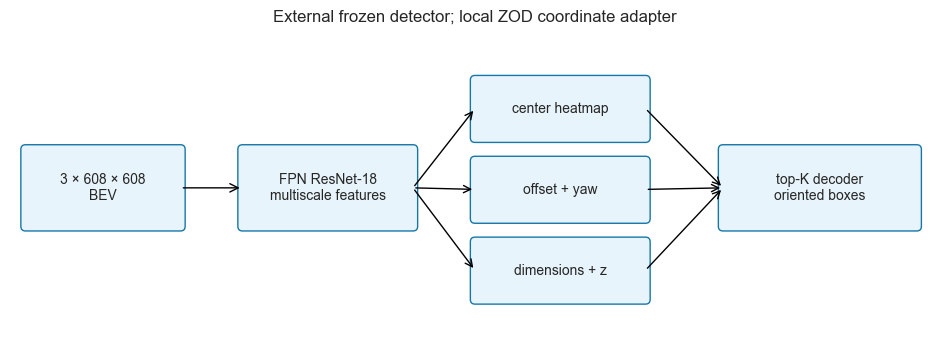

In [3]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig,ax=plt.subplots(figsize=(12,4)); ax.set_xlim(0,12); ax.set_ylim(0,4); ax.axis('off')
nodes=[(.2,1.45,2.0,1.0,'3 × 608 × 608\nBEV'),(3.0,1.45,2.2,1.0,'FPN ResNet-18\nmultiscale features'),
       (6.0,2.6,2.2,.75,'center heatmap'),(6.0,1.55,2.2,.75,'offset + yaw'),
       (6.0,.5,2.2,.75,'dimensions + z'),(9.2,1.45,2.5,1.0,'top-K decoder\noriented boxes')]
for x,y,w,h,label in nodes:
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle='round,pad=.06',fc='#e8f4fb',ec='#1677a7'))
    ax.text(x+w/2,y+h/2,label,ha='center',va='center')
ax.add_patch(FancyArrowPatch((2.2,1.95),(3,1.95),arrowstyle='->',mutation_scale=15))
for y in (2.98,1.93,.88):
    ax.add_patch(FancyArrowPatch((5.2,1.95),(6,y),arrowstyle='->',mutation_scale=13))
    ax.add_patch(FancyArrowPatch((8.2,y),(9.2,1.95),arrowstyle='->',mutation_scale=13))
ax.set_title('External frozen detector; local ZOD coordinate adapter'); plt.show()

## What training losses produced the checkpoint?

Although this project does not retrain SFA3D, understanding its outputs matters.
A CenterNet-style objective uses focal loss on the center heatmap and masked
regression losses at true object centers for offset, direction, height, and
dimensions. Schematically,

\[
\mathcal L=\mathcal L_{focal}(\hat H,H)
+\lambda_o\|\hat o-o\|_1
+\lambda_d\|\hat d-d\|_1
+\lambda_\psi\|\hat q-q\|_1
+\lambda_z\|\hat z-z\|_1.
\]

Only peaks at inference become `BEVDetection(class, x, y, length, width, yaw,
confidence)`. The adapter never retrains or silently recalibrates the checkpoint
on the 12 ZOD mini frames.

## Oriented intersection-over-union

Axis-aligned IoU would reward a box with the wrong heading. I construct each
footprint by rotating local corners with

\[
R(\psi)=\begin{bmatrix}\cos\psi&-\sin\psi\\\sin\psi&\cos\psi\end{bmatrix},
\]

clip the two convex polygons, and report

\[
IoU_{BEV}=\frac{|P\cap G|}{|P|+|G|-|P\cap G|}.
\]

Predictions and labels are greedily matched one-to-one, class consistently, in
descending IoU order at (IoU\ge0.5). Precision measures false alarms; recall
measures missed annotated objects; matched center error measures localization.

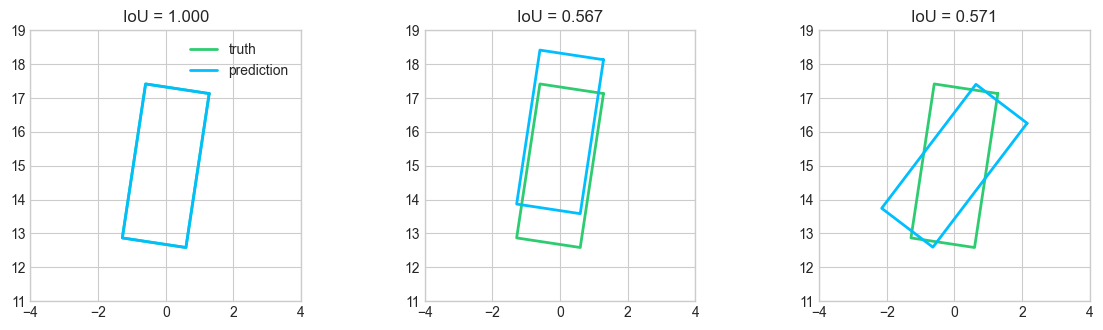

In [4]:
from zod_driveformer.bev import BEVDetection, oriented_bev_iou
from zod_driveformer.bev.evaluation import _corners
truth=BEVDetection('Vehicle',15,0,4.6,1.9,.15)
candidates=[BEVDetection('Vehicle',15+e,0,4.6,1.9,.15+a) for e,a in [(0,0),(1,0),(0,.5)]]
fig,axes=plt.subplots(1,3,figsize=(12,3.4))
for ax,pred in zip(axes,candidates):
    for box,color,label in [(truth,'#2ecc71','truth'),(pred,'#00bfff','prediction')]:
        corners=_corners(box); closed=np.vstack((corners,corners[0])); ax.plot(closed[:,1],closed[:,0],color=color,lw=2,label=label)
    ax.set_aspect('equal'); ax.set_xlim(-4,4); ax.set_ylim(11,19); ax.set_title(f'IoU = {oriented_bev_iou(pred,truth):.3f}')
axes[0].legend(); plt.tight_layout(); plt.show()

## Tracking: state, prediction, update

Each class-aware track uses state (mathbf s=[x,y,v_x,v_y]^\top). For elapsed
time (Delta t), constant-velocity prediction is

\[
\mathbf s^-_k=F\mathbf s_{k-1},\quad
P^-_k=FP_{k-1}F^\top+Q,
\quad
F=\begin{bmatrix}1&0&\Delta t&0\\0&1&0&\Delta t\\0&0&1&0\\0&0&0&1\end{bmatrix}.
\]

For measured center (mathbf z=[x,y]^\top), the Kalman update is

\[
K=P^-H^\top(HP^-H^\top+R)^{-1},\quad
\mathbf s=\mathbf s^-+K(\mathbf z-H\mathbf s^-).
\]

Class-consistent nearest-neighbor association is gated at 4 m. A track needs two
hits before display and is deleted after two misses in the animation. This is a
transparent teaching tracker, not a claim of state-of-the-art MOT accuracy.

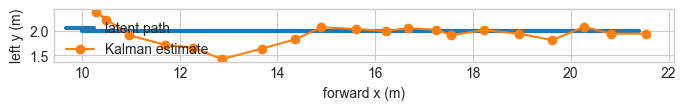

In [5]:
from zod_driveformer.bev import MultiObjectTracker
tracker=MultiObjectTracker(minimum_hits=1,maximum_misses=2)
track_xy=[]
for t in np.arange(0,4,.2):
    noisy=BEVDetection('Vehicle',10+3*t+rng.normal(0,.25),2+rng.normal(0,.25),4.5,1.9,0,0.8)
    estimate=tracker.step([noisy],dt=.2)[0]; track_xy.append((estimate.x_m,estimate.y_m,estimate.velocity_x_mps))
track_xy=np.asarray(track_xy)
fig,ax=plt.subplots(figsize=(8,3.5)); ax.plot(10+3*np.arange(0,4,.2),np.full(20,2),label='latent path',lw=3)
ax.plot(track_xy[:,0],track_xy[:,1],'o-',label='Kalman estimate'); ax.set_aspect('equal'); ax.set_xlabel('forward x (m)'); ax.set_ylabel('left y (m)'); ax.legend(); plt.show()

## Fixed evaluation contract

- Data: all 12 annotated frames in ZOD Frames mini.
- Targets: non-unclear Vehicle, Pedestrian, and VulnerableVehicle 3-D boxes,
  converted into ego-frame Vehicle, Pedestrian, and Cyclist footprints.
- Scope: target centers inside the 50 m × 50 m front raster.
- Frozen model: SFA3D FPN-ResNet-18 at a pinned source commit and checkpoint hash.
- No ZOD fine-tuning, confidence sweep, per-frame persistence, or attractive-case
  selection affects the reported metrics.

This small subset can expose domain-transfer failure; it cannot establish broad
detector quality. The qualitative montage uses the first three sorted mini
frames, a deterministic rule fixed independently of outcomes.

In [6]:
bev_report=json.loads((ROOT/'reports/bev_detection_mini.json').read_text())
evaluation=bev_report['evaluation']; rows=[]
for name,metrics in [('All',evaluation['all']),*evaluation['by_class'].items()]:
    rows.append([name,metrics['precision'],metrics['recall'],metrics['f1'],metrics['mean_matched_iou'],metrics['mean_center_error_m']])
bev_table=pd.DataFrame(rows,columns=['class','precision','recall','F1','matched IoU','center error (m)'])
bev_table.round(3)

,class,precision,recall,F1,matched IoU,center error (m)
0,All,0.809,0.365,0.503,0.718,0.293
1,Cyclist,0.000,0.000,0.000,0.000,0.000
2,Pedestrian,0.000,0.000,0.000,0.000,0.000
3,Vehicle,0.864,0.528,0.655,0.718,0.293


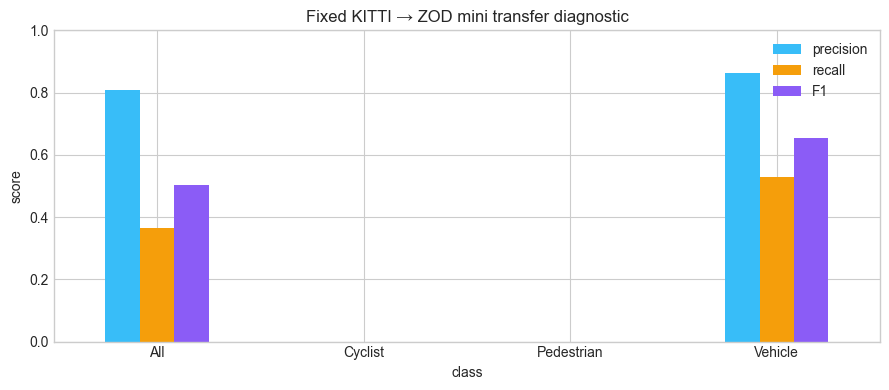

In [7]:
plot=bev_table.set_index('class')[['precision','recall','F1']]
ax=plot.plot.bar(figsize=(9,4),color=['#38bdf8','#f59e0b','#8b5cf6'])
ax.set_ylim(0,1); ax.set_ylabel('score'); ax.set_title('Fixed KITTI → ZOD mini transfer diagnostic')
ax.legend(loc='upper right'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Reading the result honestly

Vehicle localization transfers surprisingly well when a match exists: vehicle
precision is 0.864, recall 0.528, matched IoU 0.718, and matched-center error
0.293 m. Overall F1 is 0.503 across 104 targets.

The failure is just as important: pedestrian and cyclist true positives are
zero. KITTI-to-ZOD differences in class appearance, density, sensor setup, and
decoding are too large for this fixed checkpoint. A Tesla-like picture is not
evidence of a safe perception stack. The appropriate next experiment is a
proper ZOD train/validation/test detector benchmark (and possibly camera–LiDAR
fusion), not threshold tuning on these 12 evaluation frames.

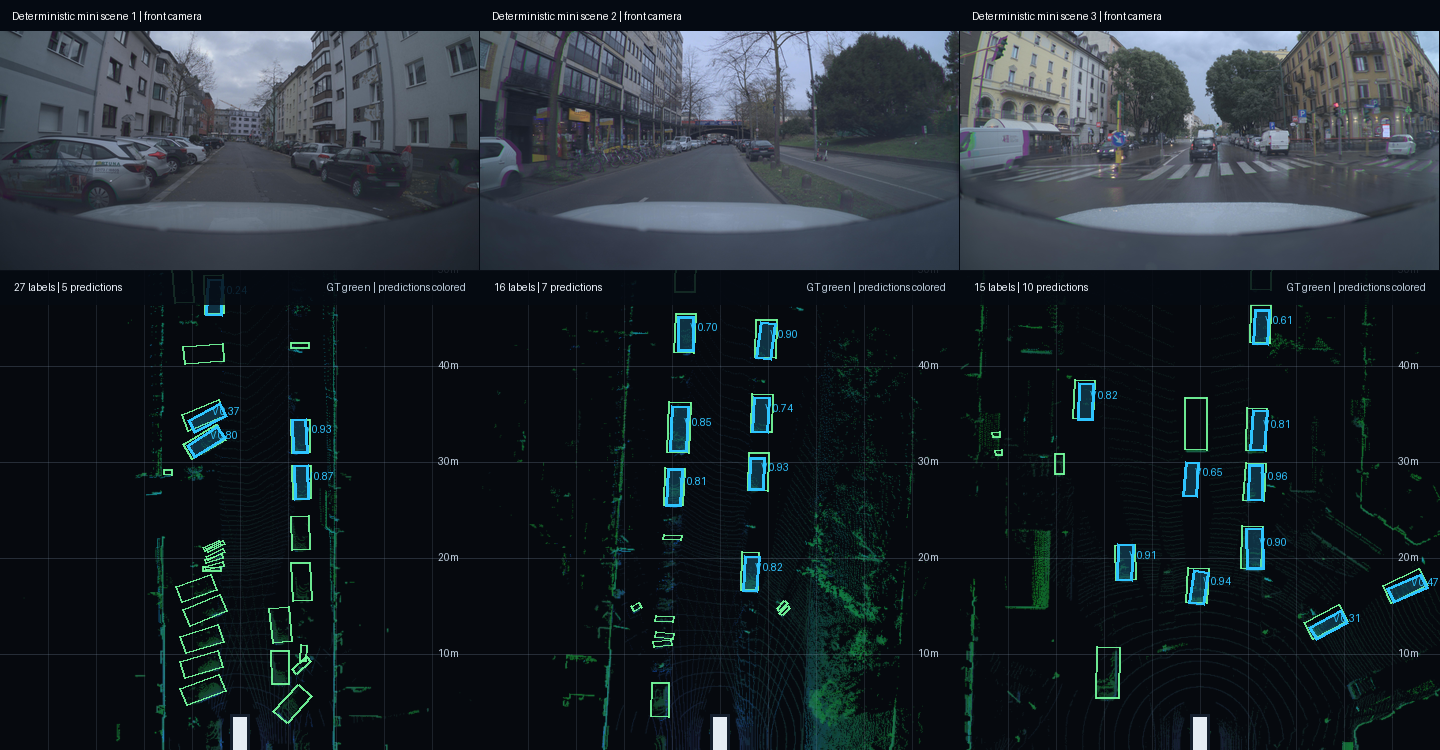

In [8]:
from IPython.display import Image as NotebookImage, display
display(NotebookImage(filename=str(ROOT/'reports/figures/bev_detection_mini.png')))

The green rectangles above are ZOD ground-truth footprints; cyan, orange, and
purple are model predictions. The front-camera row is context only—the LiDAR
detector never receives RGB. The point-cloud background makes occlusion and
sparse returns visible rather than presenting boxes on an unexplained blank map.

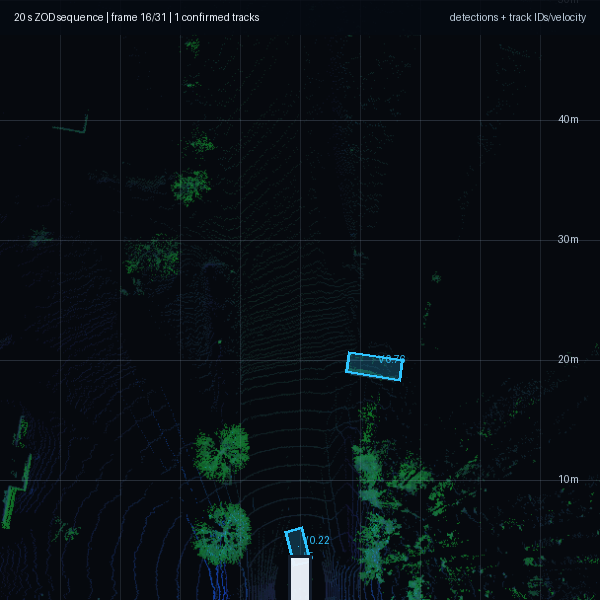

In [9]:
display(NotebookImage(filename=str(ROOT/'reports/figures/bev_tracking.png')))

## Reproduction and review checklist

1. Keep ZOD, the pinned SFA3D source, and its checkpoint outside Git.
2. Rebuild `reports/bev_detection_mini.json` with
   `scripts/evaluate_bev_detection.py`; all paths are explicit CLI arguments.
3. Rebuild the montage/GIF with `scripts/build_bev_visuals.py`.
4. Verify the checkpoint SHA-256 and external source commit in the report.
5. Inspect oriented-IoU, coordinate-transform, raster, and tracker tests.
6. Do not call the animated sequence a tracking benchmark: it is a qualitative
   demonstration because that sequence has no frame-by-frame 3-D box labels.

The complete animation is embedded in the README. Raw point clouds, images,
annotations, checkpoint weights, identifiers, and per-frame predictions remain
outside the repository.